In [1]:
import joblib

# โหลด vectorizer
vectorizer = joblib.load('../Features/result/vectorizer-new.pkl')

# โหลด X_tfidf
X_tfidf = joblib.load('../Features/result/X_tfidf-new.pkl')
X_additional = joblib.load('../Features/result/X_additional-new.pkl')

# โหลด y_under
y_under = joblib.load('../InitData/result/y_under.pkl')

print("✅ โหลดข้อมูลเรียบร้อยแล้ว!")


✅ โหลดข้อมูลเรียบร้อยแล้ว!


In [2]:
print(y_under)

[0 0 0 ... 1 1 1]


In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, Concatenate
import tensorflow.keras.backend as K

def build_multi_output_model(input_dim):
    # Input layer
    input_layer = Input(shape=(input_dim,))
    
    # Shared layers
    x = Dense(512, activation='relu')(input_layer)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    # Separate branches for different outputs
    # 1. Main classification output (Real/Fake)
    main_output = Dense(1, activation='sigmoid', name='main_output')(x)
    
    # 2. Source credibility score
    source_hidden = Dense(64, activation='relu')(x)
    source_output = Dense(1, activation='sigmoid', name='source_output')(source_hidden)
    
    # 3. Language structure score
    lang_hidden = Dense(64, activation='relu')(x)
    lang_output = Dense(1, activation='sigmoid', name='lang_output')(lang_hidden)
    
    # 4. Factual accuracy score
    fact_hidden = Dense(64, activation='relu')(x)
    fact_output = Dense(1, activation='sigmoid', name='fact_output')(fact_hidden)
    
    # 5. Cross-source consistency score
    cross_hidden = Dense(64, activation='relu')(x)
    cross_output = Dense(1, activation='sigmoid', name='cross_output')(cross_hidden)
    
    # Create model with multiple outputs
    model = Model(
        inputs=input_layer, 
        outputs=[
            main_output,
            source_output,
            lang_output,
            fact_output,
            cross_output
        ]
    )
    
    # Custom loss weights for each output
    loss_weights = {
        'main_output': 1.0,      # Main classification task
        'source_output': 0.5,    # Source credibility
        'lang_output': 0.3,      # Language structure
        'fact_output': 0.5,      # Factual accuracy
        'cross_output': 0.4      # Cross-source consistency
    }
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss={
            'main_output': 'binary_crossentropy',
            'source_output': 'binary_crossentropy',
            'lang_output': 'binary_crossentropy',
            'fact_output': 'binary_crossentropy',
            'cross_output': 'binary_crossentropy'
        },
        loss_weights=loss_weights,
        metrics={
            'main_output': 'accuracy',
            'source_output': 'accuracy',
            'lang_output': 'accuracy',
            'fact_output': 'accuracy',
            'cross_output': 'accuracy'
        }
    )
    
    return model


📂 Fold 1
Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - cross_output_accuracy: 0.8574 - cross_output_loss: 0.4605 - fact_output_accuracy: 0.7787 - fact_output_loss: 0.5144 - lang_output_accuracy: 0.9805 - lang_output_loss: 0.2438 - loss: 1.1497 - main_output_accuracy: 0.8303 - main_output_loss: 0.4066 - source_output_accuracy: 0.8550 - source_output_loss: 0.4571 - val_cross_output_accuracy: 0.8987 - val_cross_output_loss: 0.3150 - val_fact_output_accuracy: 0.8092 - val_fact_output_loss: 0.3919 - val_lang_output_accuracy: 1.0000 - val_lang_output_loss: 3.7191e-04 - val_loss: 0.5859 - val_main_output_accuracy: 0.9658 - val_main_output_loss: 0.0868 - val_source_output_accuracy: 0.8634 - val_source_output_loss: 0.3511 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - cross_output_accuracy: 0.9022 - cross_output_loss: 0.2801 - fact_output_accuracy: 0.8452 - fact_output_loss: 0.3254 - lang_output_accuracy: 1.0000 - lang_output_loss: 2.2070e-04 - loss: 0

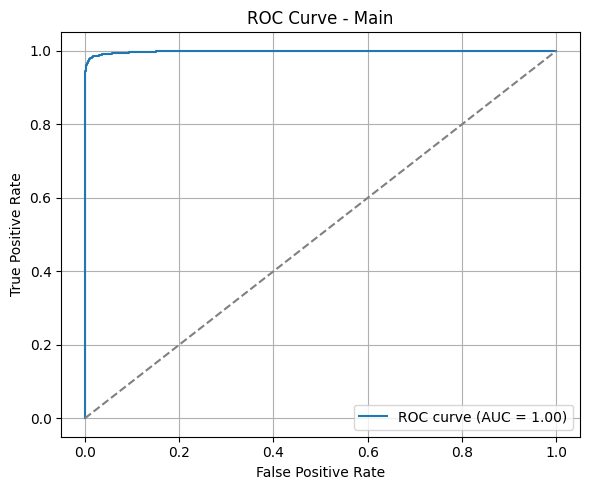


📊 Source Metrics:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92      3719
         1.0       0.39      0.26      0.32       526

    accuracy                           0.86      4245
   macro avg       0.65      0.60      0.62      4245
weighted avg       0.84      0.86      0.85      4245

Confusion Matrix:
[[3502  217]
 [ 387  139]]

📊 Lang Metrics:
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00      4245

    accuracy                           1.00      4245
   macro avg       1.00      1.00      1.00      4245
weighted avg       1.00      1.00      1.00      4245

Confusion Matrix:
[[4245]]

📊 Fact Metrics:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.92      0.90      3313
         1.0       0.68      0.59      0.63       932

    accuracy                           0.8

C:\Users\SUPHASET\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [3]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ------------------------------
# เตรียมข้อมูล
# ------------------------------
X_dense = X_tfidf.toarray().astype(np.float32)
y = y_under  # Binary: [0, 0, 1, 1, ...]

# สร้าง proxy targets สำหรับ outputs อื่นๆ
# (ในที่นี้ใช้ features ที่สร้างขึ้นมาเป็น targets)
source_y = (X_additional[:, :5].mean(axis=1) > 0.5).astype(np.float32)
lang_y = (X_additional[:, 5:8].mean(axis=1) > 0.5).astype(np.float32)
fact_y = (X_additional[:, 8:12].mean(axis=1) > 0.5).astype(np.float32)
cross_y = (X_additional[:, 12:].mean(axis=1) > 0.5).astype(np.float32)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_metrics = {
    'main_output': {'true': [], 'pred': [], 'proba': []},
    'source_output': {'true': [], 'pred': []},
    'lang_output': {'true': [], 'pred': []},
    'fact_output': {'true': [], 'pred': []},
    'cross_output': {'true': [], 'pred': []}
}

# ------------------------------
# Cross-validation loop
# ------------------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(X_dense, y), 1):
    print(f"\n📂 Fold {fold}")

    # Split data
    X_train, X_val = X_dense[train_idx], X_dense[val_idx]
    y_train = {
        'main_output': y[train_idx],
        'source_output': source_y[train_idx],
        'lang_output': lang_y[train_idx],
        'fact_output': fact_y[train_idx],
        'cross_output': cross_y[train_idx]
    }
    y_val = {
        'main_output': y[val_idx],
        'source_output': source_y[val_idx],
        'lang_output': lang_y[val_idx],
        'fact_output': fact_y[val_idx],
        'cross_output': cross_y[val_idx]
    }

    model = build_multi_output_model(input_dim=X_train.shape[1])

    early_stop = EarlyStopping(
        monitor='val_main_output_loss',
        mode='min', 
        patience=3,
        restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_main_output_loss',
        mode='min', 
        factor=0.1,
        patience=2
    )

    # Train model
    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Get predictions
    val_pred = model.predict(X_val)
    
    # Store metrics for each output
    outputs = ['main_output', 'source_output', 'lang_output', 'fact_output', 'cross_output']
    for i, output in enumerate(outputs):
        if output == 'main_output':
            all_metrics[output]['proba'].extend(val_pred[i].ravel())
        all_metrics[output]['true'].extend(y_val[output])
        all_metrics[output]['pred'].extend((val_pred[i].ravel() > 0.5).astype(int))

# ------------------------------
# แสดงผลการทำนายรวมทุก fold
# ------------------------------
print("\n✨ ผลการทำนายรวมทุก fold:")

for output in outputs:
    print(f"\n📊 {output.replace('_output', '').title()} Metrics:")
    print("Classification Report:")
    print(classification_report(
        all_metrics[output]['true'],
        all_metrics[output]['pred']
    ))
    
    print("Confusion Matrix:")
    print(confusion_matrix(
        all_metrics[output]['true'],
        all_metrics[output]['pred']
    ))
    
    if output == 'main_output':
        # Plot ROC curve for main output
        fpr, tpr, _ = roc_curve(
            all_metrics[output]['true'],
            all_metrics[output]['proba']
        )
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {output.replace('_output', '').title()}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [4]:
# บันทึกโมเดลที่ฝึกแล้ว
model.save(f'result/models/model_fold_{fold}_new.h5')  # Save the model after each fold
print(f"✅ โมเดลที่ฝึกใน fold {fold} ถูกบันทึกแล้ว!")

✅ โมเดลที่ฝึกใน fold 5 ถูกบันทึกแล้ว!
